# CCS2213: Machine Learning Assignment 1

## Start-up Success Prediction
**Dataset:** startup data.csv (Crunchbase via Kaggle)  
**Models:** Random Forest, Logistic Regression & K-Nearest Neighbor(KNN)

## 1.0 Exploratory Data Analysis (EDA)
### 1. Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

df = pd.read_csv('startup data.csv')

print('Top 5 Records')
display(df.head())

Top 5 Records


,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
0,1005,CA,42.358880,-71.056820,92101,c:6669,San Diego,NaN,Bandsintown,1,...,c:6669,0,1,0,0,0,0,1.0000,0,acquired
1,204,CA,37.238916,-121.973718,95032,c:16283,Los Gatos,NaN,TriCipher,1,...,c:16283,1,0,0,1,1,1,4.7500,1,acquired
2,1001,CA,32.901049,-117.192656,92121,c:65620,San Diego,San Diego CA 92121,Plixi,1,...,c:65620,0,0,1,0,0,0,4.0000,1,acquired
3,738,CA,37.320309,-122.050040,95014,c:42668,Cupertino,Cupertino CA 95014,Solidcore Systems,1,...,c:42668,0,0,0,1,1,1,3.3333,1,acquired
4,1002,CA,37.779281,-122.419236,94105,c:65806,San Francisco,San Francisco CA 94105,Inhale Digital,0,...,c:65806,1,1,0,0,0,0,1.0000,1,closed


In [2]:
print('\n--- Last 5 Records ---')
display(df.tail())


--- Last 5 Records ---


,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
918,352,CA,37.740594,-122.376471,94107,c:21343,San Francisco,NaN,CoTweet,1,...,c:21343,0,0,1,0,0,0,6.0000,1,acquired
919,721,MA,42.504817,-71.195611,1803,c:41747,Burlington,Burlington MA 1803,Reef Point Systems,0,...,c:41747,1,0,0,1,0,0,2.6667,1,closed
920,557,CA,37.408261,-122.015920,94089,c:31549,Sunnyvale,NaN,Paracor Medical,0,...,c:31549,0,0,0,0,0,1,8.0000,1,closed
921,589,CA,37.556732,-122.288378,94404,c:33198,San Francisco,NaN,Causata,1,...,c:33198,0,0,1,1,0,0,1.0000,1,acquired
922,462,CA,37.386778,-121.966277,95054,c:26702,Santa Clara,Santa Clara CA 95054,Asempra Technologies,1,...,c:26702,0,0,0,1,0,0,3.0000,1,acquired


In [44]:
print('\n  Data Information and Structure ')
df.info()


  Data Information and Structure 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                923 non-null    int64  
 1   state_code                923 non-null    object 
 2   latitude                  923 non-null    float64
 3   longitude                 923 non-null    float64
 4   zip_code                  923 non-null    object 
 5   id                        923 non-null    object 
 6   city                      923 non-null    object 
 7   Unnamed: 6                430 non-null    object 
 8   name                      923 non-null    object 
 9   labels                    923 non-null    int64  
 10  founded_at                923 non-null    object 
 11  closed_at                 335 non-null    object 
 12  first_funding_at          923 non-null    object 
 13  last_funding_at           923 

In [43]:
print('\n Descriptive Statistics ')
display(df.describe())


 Descriptive Statistics 


,Unnamed: 0,latitude,longitude,labels,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,...,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,target
count,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,771.000000,771.000000,923.000000,923.000000,...,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000
mean,572.297941,38.517442,-103.539212,0.646804,2.235630,3.931456,3.055353,4.754423,7.710726,2.310943,...,0.322860,0.326111,0.254605,0.508126,0.392199,0.232936,0.099675,2.838586,0.809317,0.646804
std,333.585431,3.741497,22.394167,0.478222,2.510449,2.967910,2.977057,3.212107,7.265776,1.390922,...,0.467823,0.469042,0.435875,0.500205,0.488505,0.422931,0.299729,1.874601,0.393052,0.478222
min,1.000000,25.752358,-122.756956,0.000000,-9.046600,-9.046600,-14.169900,-7.005500,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,283.500000,37.388869,-122.198732,0.000000,0.576700,1.669850,1.000000,2.411000,3.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,1.000000,0.000000
50%,577.000000,37.779281,-118.374037,1.000000,1.446600,3.528800,2.520500,4.476700,5.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.500000,1.000000,1.000000
75%,866.500000,40.730646,-77.214731,1.000000,3.575350,5.560250,4.686300,6.753400,10.000000,3.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,3.800000,1.000000,1.000000
max,1153.000000,59.335232,18.057121,1.000000,21.895900,21.895900,24.684900,24.684900,63.000000,10.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,16.000000,1.000000,1.000000


In [42]:
print('\n Dataset Shape ')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')


 Dataset Shape 
Rows: 923, Columns: 50


### 2. Data Distribution

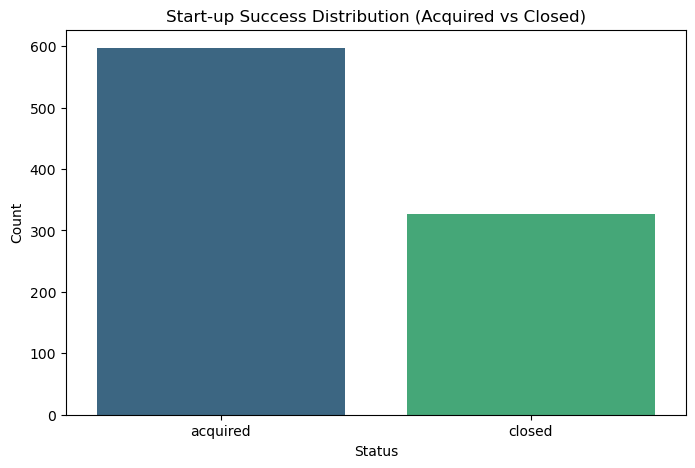

Class Percentages:
 status
acquired    64.68039
closed      35.31961
Name: proportion, dtype: float64


In [6]:
# Class distribution bar chart
plt.figure(figsize=(8, 5))
sns.countplot(x='status', data=df, palette='viridis')
plt.title('Start-up Success Distribution (Acquired vs Closed)')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

distribution = df['status'].value_counts(normalize=True) * 100
print('Class Percentages:\n', distribution)

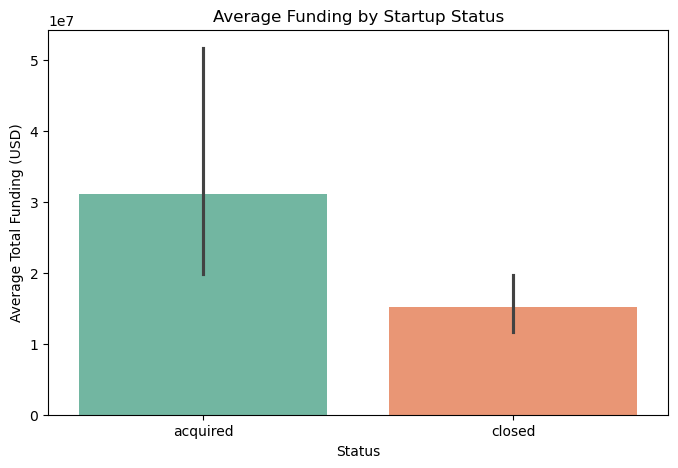

In [7]:
plt.figure(figsize=(8, 5))
sns.barplot(x='status', y='funding_total_usd', data=df, palette='Set2')
plt.title('Average Funding by Startup Status')
plt.xlabel('Status')
plt.ylabel('Average Total Funding (USD)')
plt.show()

### 3. Relationships

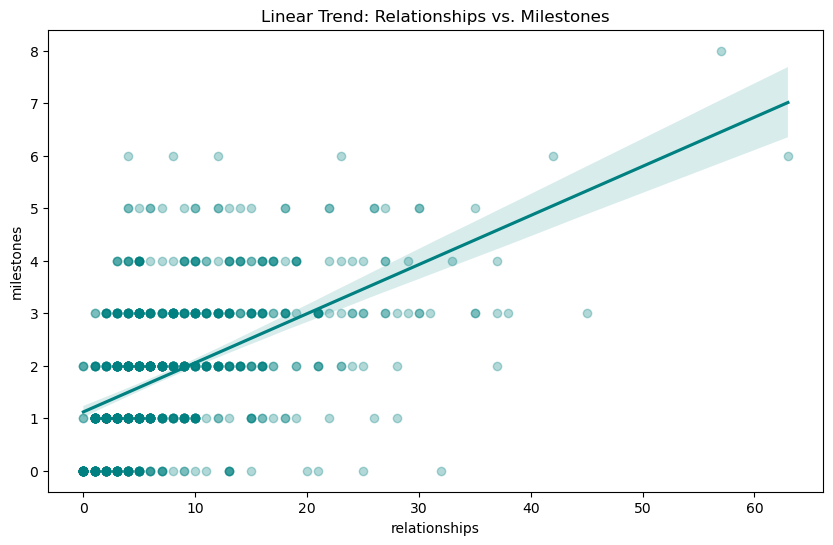

In [8]:
plt.figure(figsize=(10, 6))
sns.regplot(x='relationships', y='milestones', data=df,
            scatter_kws={'alpha': 0.3}, color='teal')
plt.title('Linear Trend: Relationships vs. Milestones')
plt.show()

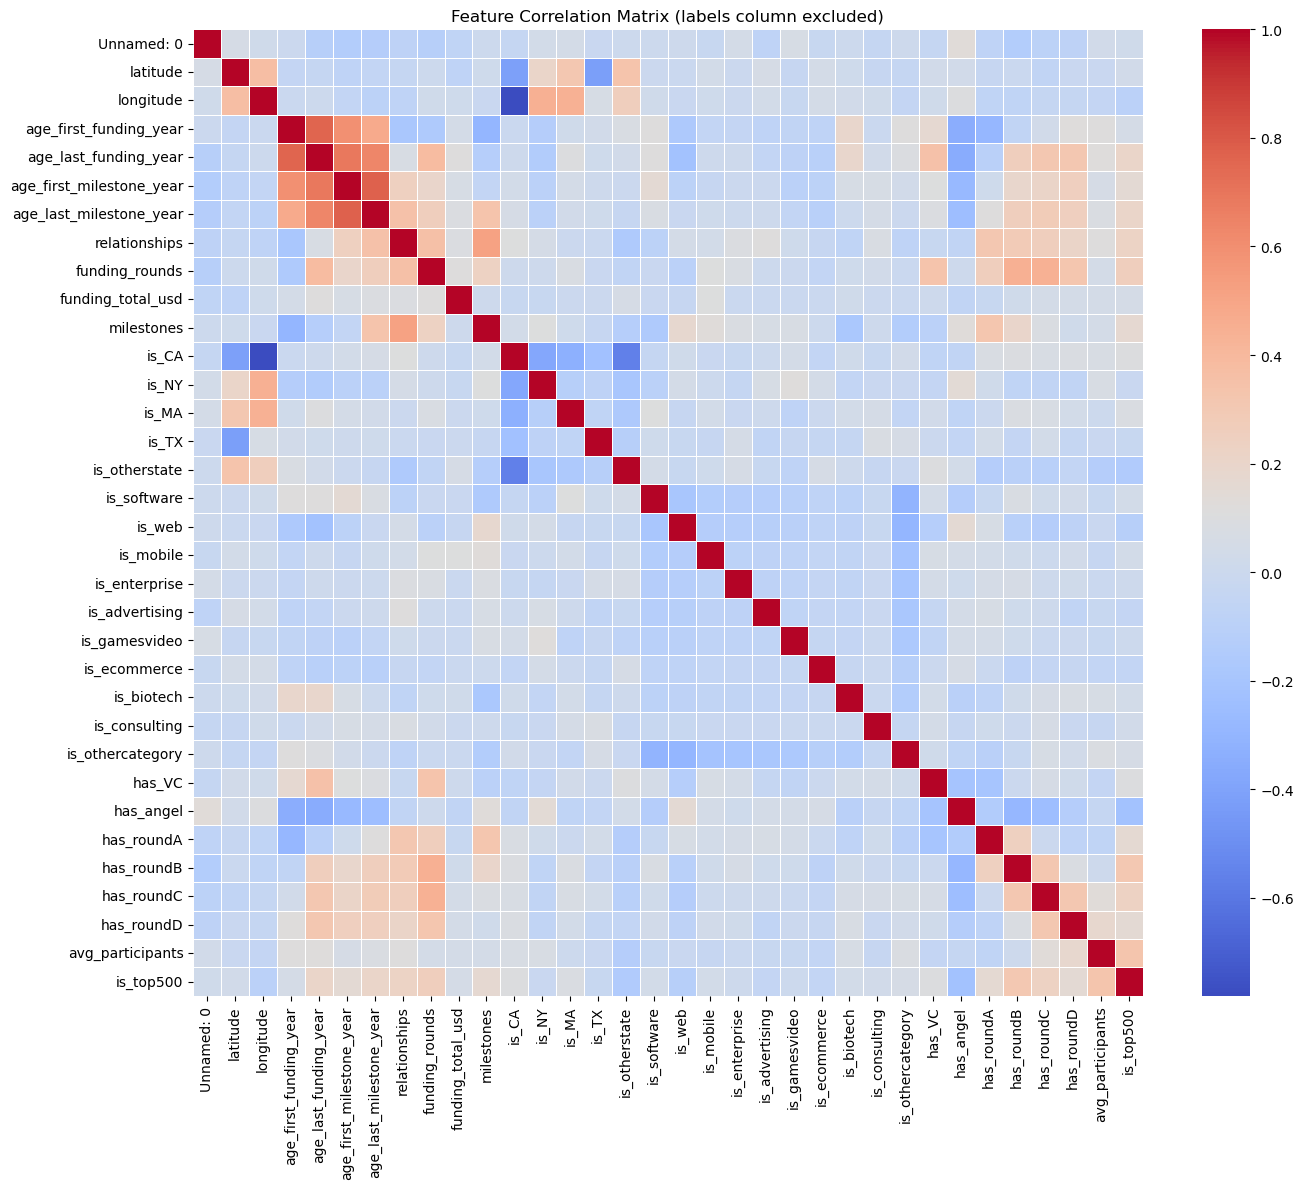

In [9]:
numeric_df = df.select_dtypes(include=[np.number])
numeric_df_clean = numeric_df.drop(columns=['labels'], errors='ignore')

plt.figure(figsize=(14, 12))
sns.heatmap(numeric_df_clean.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix (labels column excluded)')
plt.tight_layout()
plt.show()

## 2.0 Data Pre-processing

### 1. Drop Leakage & Irrelevant Columns

In [10]:
cols_to_drop = [
    'labels',
    'closed_at',
    'Unnamed: 0',
    'Unnamed: 6',
    'id',
    'object_id',
    'name',
    'zip_code',
    'state_code.1',
    'founded_at',
    'first_funding_at',
    'last_funding_at',
]

df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
print('Columns after dropping leakage/irrelevant columns:')
print(df.columns.tolist())
print(f'\nShape: {df.shape}')

Columns after dropping leakage/irrelevant columns:
['state_code', 'latitude', 'longitude', 'city', 'age_first_funding_year', 'age_last_funding_year', 'age_first_milestone_year', 'age_last_milestone_year', 'relationships', 'funding_rounds', 'funding_total_usd', 'milestones', 'is_CA', 'is_NY', 'is_MA', 'is_TX', 'is_otherstate', 'category_code', 'is_software', 'is_web', 'is_mobile', 'is_enterprise', 'is_advertising', 'is_gamesvideo', 'is_ecommerce', 'is_biotech', 'is_consulting', 'is_othercategory', 'has_VC', 'has_angel', 'has_roundA', 'has_roundB', 'has_roundC', 'has_roundD', 'avg_participants', 'is_top500', 'status']

Shape: (923, 37)


### 1b. Data Cleaning: Drop Redundant Geographic Columns

In [11]:
geo_cols_to_drop = ['latitude', 'longitude']
df.drop(columns=[c for c in geo_cols_to_drop if c in df.columns], inplace=True)

print('Shape after dropping redundant geographic columns:', df.shape)
print('Remaining columns:', df.columns.tolist())

Shape after dropping redundant geographic columns: (923, 35)
Remaining columns: ['state_code', 'city', 'age_first_funding_year', 'age_last_funding_year', 'age_first_milestone_year', 'age_last_milestone_year', 'relationships', 'funding_rounds', 'funding_total_usd', 'milestones', 'is_CA', 'is_NY', 'is_MA', 'is_TX', 'is_otherstate', 'category_code', 'is_software', 'is_web', 'is_mobile', 'is_enterprise', 'is_advertising', 'is_gamesvideo', 'is_ecommerce', 'is_biotech', 'is_consulting', 'is_othercategory', 'has_VC', 'has_angel', 'has_roundA', 'has_roundB', 'has_roundC', 'has_roundD', 'avg_participants', 'is_top500', 'status']


### 2. Handling Missing Values

In [12]:
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
age_first_milestone_year    152
age_last_milestone_year     152
dtype: int64


In [13]:
df.fillna(df.median(numeric_only=True), inplace=True)

for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print('Missing values after treatment:', df.isnull().sum().sum())

Missing values after treatment: 0


### 3. Encoding Categorical Variables

In [14]:
df['status'] = df['status'].map({'acquired': 1, 'closed': 0})

categorical_cols = ['category_code', 'state_code', 'city']
categorical_cols = [c for c in categorical_cols if c in df.columns]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f'Shape after encoding: {df.shape}')
display(df.head())

Shape after encoding: (923, 320)


,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,is_CA,is_NY,...,city_Westford,city_Weston,city_Westport,city_Williamstown,city_Wilmington,city_Woburn,city_Woodbury,city_Yardley,city_Yorba Linda,city_Zeeland
0,2.2493,3.0027,4.6685,6.7041,3,3,375000,3,1,0,...,False,False,False,False,False,False,False,False,False,False
1,5.1260,9.9973,7.0055,7.0055,9,4,40100000,1,1,0,...,False,False,False,False,False,False,False,False,False,False
2,1.0329,1.0329,1.4575,2.2055,5,1,2600000,2,1,0,...,False,False,False,False,False,False,False,False,False,False
3,3.1315,5.3151,6.0027,6.0027,5,3,40000000,1,1,0,...,False,False,False,False,False,False,False,False,False,False
4,0.0000,1.6685,0.0384,0.0384,2,2,1300000,1,1,0,...,False,False,False,False,False,False,False,False,False,False


### 4. Outlier Handling (IQR Capping)

In [15]:
Q1 = df['funding_total_usd'].quantile(0.25)
Q3 = df['funding_total_usd'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['funding_total_usd'] = np.where(
    df['funding_total_usd'] > upper_bound, upper_bound,
    np.where(df['funding_total_usd'] < lower_bound, lower_bound,
             df['funding_total_usd'])
)

print('Outliers in funding_total_usd have been capped using the IQR method.')

Outliers in funding_total_usd have been capped using the IQR method.


## 3.0 Train/Test Split

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X = df.select_dtypes(include=[np.number]).drop('status', axis=1)
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size : {X_train.shape[0]} samples')
print(f'Test set size     : {X_test.shape[0]} samples')
print(f'\nClass distribution in training set:')
print(y_train.value_counts())
print(f'\nClass distribution in test set:')
print(y_test.value_counts())

Training set size : 738 samples
Test set size     : 185 samples

Class distribution in training set:
status
1    477
0    261
Name: count, dtype: int64

Class distribution in test set:
status
1    120
0     65
Name: count, dtype: int64


#### Feature Scaling

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)         # transform test with train stats

print('Feature scaling applied. Sample of scaled training data:')
display(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

Feature scaling applied. Sample of scaled training data:


,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,is_CA,is_NY,...,is_consulting,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500
0,-0.153973,-0.222365,0.100918,0.958946,1.109078,-0.253257,0.016386,1.591304,-1.064400,-0.351123,...,-0.052129,-0.674997,-0.702799,-0.584652,0.970621,1.191500,-0.557526,-0.326262,-0.182050,0.477445
1,-0.518422,-0.456339,-0.013385,-0.275303,-0.393508,-0.253257,-0.103548,0.083753,-1.064400,-0.351123,...,-0.052129,-0.674997,-0.702799,-0.584652,0.970621,1.191500,-0.557526,-0.326262,-0.447537,0.477445
2,1.302783,0.499797,-0.167728,-0.104280,-0.393508,-0.992006,0.753125,-1.423799,0.939496,-0.351123,...,-0.052129,1.481487,-0.702799,-0.584652,-1.030268,-0.839278,1.793640,-0.326262,1.676357,0.477445
3,2.125838,1.192506,1.431315,0.749081,-0.256909,-0.992006,-0.103548,-0.670023,0.939496,-0.351123,...,-0.052129,1.481487,-0.702799,-0.584652,-1.030268,-0.839278,-0.557526,3.065023,1.676357,0.477445
4,1.142989,0.365310,0.629369,0.425494,-0.120311,-0.992006,-0.674664,0.083753,0.939496,-0.351123,...,-0.052129,-0.674997,-0.702799,-0.584652,0.970621,-0.839278,-0.557526,-0.326262,-0.978510,-2.094484


#### SMOTE:  Applied on Training Set Only

In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:')
print(pd.Series(y_train).value_counts())
print('\nAfter SMOTE:')
print(pd.Series(y_train_resampled).value_counts())

Before SMOTE:
status
1    477
0    261
Name: count, dtype: int64

After SMOTE:
status
1    477
0    477
Name: count, dtype: int64


## 4.0 Dimension Reduction

In [19]:
from sklearn.ensemble import RandomForestClassifier

fs_model = RandomForestClassifier(n_estimators=100, random_state=42)
fs_model.fit(X_train_resampled, y_train_resampled)

importances = fs_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_10 = feature_importance_df.head(10)
print('Top 10 Important Features (leakage columns removed):')
print(top_10.to_string(index=False))

Top 10 Important Features (leakage columns removed):
                 Feature  Importance
           relationships    0.146345
 age_last_milestone_year    0.095128
              milestones    0.087552
       funding_total_usd    0.079009
age_first_milestone_year    0.078037
  age_first_funding_year    0.069157
        avg_participants    0.068376
   age_last_funding_year    0.066279
          funding_rounds    0.053665
               is_top500    0.036839


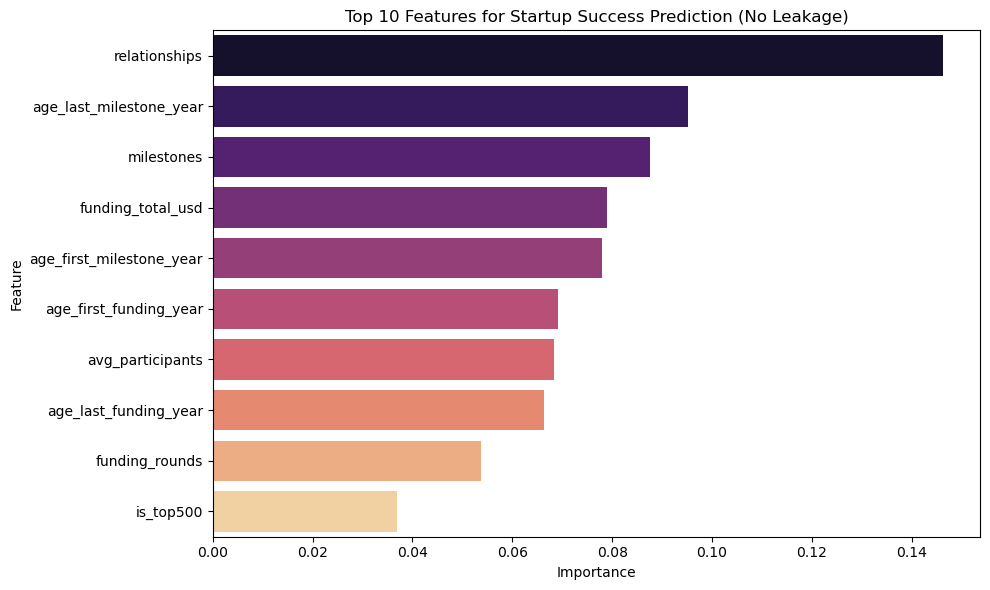

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10, palette='magma')
plt.title('Top 10 Features for Startup Success Prediction (No Leakage)')
plt.tight_layout()
plt.show()

In [21]:
top_features = top_10['Feature'].tolist()

X_train_final = pd.DataFrame(X_train_resampled, columns=X_train.columns)[top_features]
X_test_final  = pd.DataFrame(X_test_scaled,     columns=X_train.columns)[top_features]

print(f'Final training feature set shape : {X_train_final.shape}')
print(f'Final test feature set shape     : {X_test_final.shape}')

Final training feature set shape : (954, 10)
Final test feature set shape     : (185, 10)


## 5.0 Supervised Learning Models

### Model 1: Random Forest Classifier
### Model 2: Logistic Regression
### Model 3: K_Nearst Neighbors Classifier (KNN)

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE

try:
    df = pd.read_csv('startup data.csv')
    print("File 'startup data.csv' loaded successfully!")
except FileNotFoundError:
    print("ERROR: Could not find 'startup data.csv'. Please check the filename.")

if 'status' in df.columns:
    df['target'] = df['status'].map({'acquired': 1, 'closed': 0})
else:
    df['target'] = df['labels']

df_numeric = df.select_dtypes(include=['number']).fillna(0)
X = df_numeric.drop(columns=['target', 'status', 'labels', 'Unnamed: 0'], errors='ignore')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

models = {
    'Random Forest (Ensemble)': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression (Parametric)': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (Non-Parametric)': KNeighborsClassifier(n_neighbors=5)
}

results = []
for name, model in models.items():
    model.fit(X_res, y_res)
    preds = model.predict(X_test)
    results.append({
        'Model Type': name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'F1-Score': round(f1_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall': round(recall_score(y_test, preds), 4)
    })

comparison_df = pd.DataFrame(results)
display(comparison_df)

File 'startup data.csv' loaded successfully!


,Model Type,Accuracy,F1-Score,Precision,Recall
0,Random Forest (Ensemble),0.7568,0.8117,0.7638,0.8661
1,Logistic Regression (Parametric),0.6919,0.7107,0.8235,0.6250
2,KNN (Non-Parametric),0.6000,0.6696,0.6696,0.6696


## 6.0 Model Evaluation

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_final = X_train_scaled
y_train_resampled = y_train   




In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
X_train_final = X_train_resampled


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

model_rf  = RandomForestClassifier(n_estimators=100, random_state=42)
model_lr  = LogisticRegression(max_iter=1000, random_state=42)
model_knn = KNeighborsClassifier(n_neighbors=5)

print('Models initialized: Random Forest, Logistic Regression, KNN')

In [31]:
model_rf.fit(X_train_final, y_train_resampled)
model_lr.fit(X_train_final, y_train_resampled)
model_knn.fit(X_train_final, y_train_resampled)

print("All three models (RF, LR, and KNN) trained successfully.")


All three models (RF, LR, and KNN) trained successfully.


In [32]:
from sklearn.metrics import accuracy_score

for name, model in [("RF", model_rf), ("LR", model_lr), ("KNN", model_knn)]:
    y_pred = model.predict(X_test_scaled)
    print(f"{name} Accuracy:", accuracy_score(y_test, y_pred))


RF Accuracy: 0.772972972972973
LR Accuracy: 0.6864864864864865
KNN Accuracy: 0.6216216216216216


In [ ]:
# Align X_test_final with the scaled test set for evaluation
X_test_final = X_test_scaled
print('X_test_final set to X_test_scaled for model evaluation.')

In [35]:
# Updated MODEL EVALUATION (Replacing SVM with KNN)
y_pred_rf  = model_rf.predict(X_test_final)
y_pred_lr  = model_lr.predict(X_test_final)
y_pred_knn = model_knn.predict(X_test_final) # Updated to KNN

print("Predictions generated for Random Forest, Logistic Regression, and KNN.")

Predictions generated for Random Forest, Logistic Regression, and KNN.


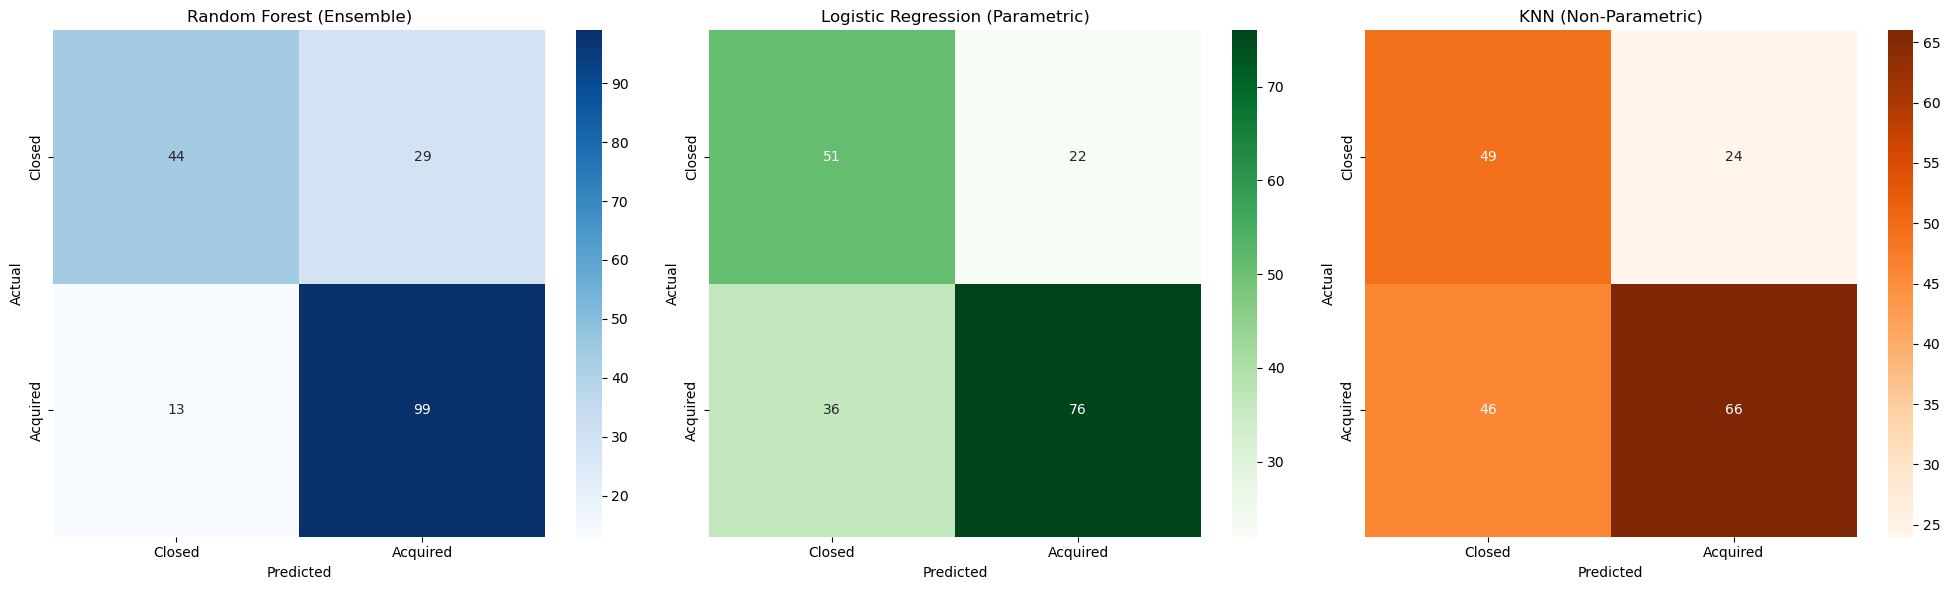

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_knn = confusion_matrix(y_test, y_pred_knn)

for ax, cm, title, cmap in zip(
    axes, 
    [cm_rf, cm_lr, cm_knn], 
    ['Random Forest (Ensemble)', 'Logistic Regression (Parametric)', 'KNN (Non-Parametric)'], 
    ['Blues', 'Greens', 'Oranges']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Closed','Acquired'], 
                yticklabels=['Closed','Acquired'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [37]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Random Forest': [
        round(accuracy_score(y_test, y_pred_rf), 4),
        round(precision_score(y_test, y_pred_rf), 4),
        round(recall_score(y_test, y_pred_rf), 4),
        round(f1_score(y_test, y_pred_rf), 4),
        round(roc_auc_score(y_test, y_pred_rf), 4),
    ],
    'Logistic Regression': [
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(precision_score(y_test, y_pred_lr), 4),
        round(recall_score(y_test, y_pred_lr), 4),
        round(f1_score(y_test, y_pred_lr), 4),
        round(roc_auc_score(y_test, y_pred_lr), 4),
    ],
    'KNN': [
        round(accuracy_score(y_test, y_pred_knn), 4),
        round(precision_score(y_test, y_pred_knn), 4),
        round(recall_score(y_test, y_pred_knn), 4),
        round(f1_score(y_test, y_pred_knn), 4),
        round(roc_auc_score(y_test, y_pred_knn), 4),
    ]
})

print('\n Final Comparative Analysis Table')
display(comparison)


===== Final Comparative Analysis Table =====


,Metric,Random Forest,Logistic Regression,KNN
0,Accuracy,0.7730,0.6865,0.6216
1,Precision,0.7734,0.7755,0.7333
2,Recall,0.8839,0.6786,0.5893
3,F1-Score,0.8250,0.7238,0.6535
4,ROC-AUC,0.7433,0.6886,0.6303


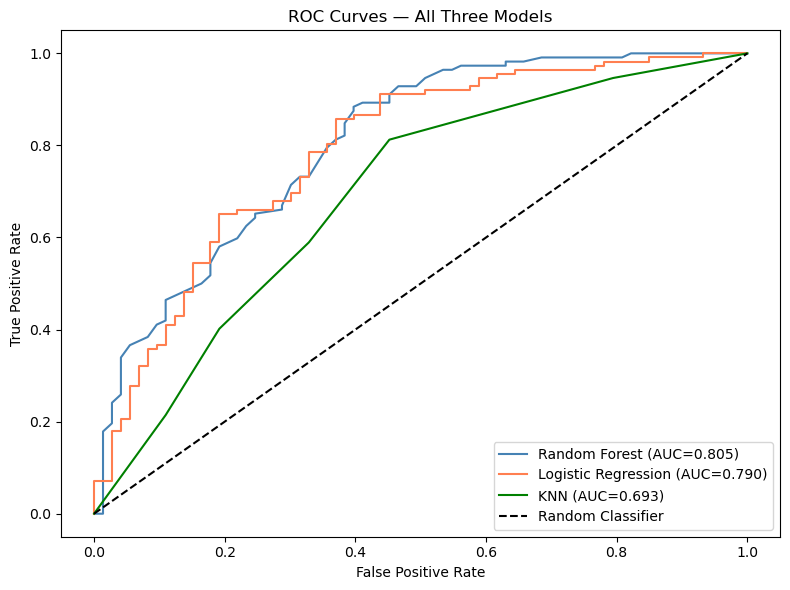

In [39]:
from sklearn.metrics import roc_curve, auc

y_prob_rf  = model_rf.predict_proba(X_test_final)[:, 1]
y_prob_lr  = model_lr.predict_proba(X_test_final)[:, 1]
y_prob_knn = model_knn.predict_proba(X_test_final)[:, 1]

fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest (AUC={auc(fpr_rf, tpr_rf):.3f})',  color='steelblue')
plt.plot(fpr_lr,  tpr_lr,  label=f'Logistic Regression (AUC={auc(fpr_lr, tpr_lr):.3f})', color='coral')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC={auc(fpr_knn, tpr_knn):.3f})',           color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Three Models')
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
rf_f1 = f1_score(y_test, y_pred_rf)
lr_f1 = f1_score(y_test, y_pred_lr)
knn_f1 = f1_score(y_test, y_pred_knn)

f1_scores = {
    'Random Forest': rf_f1,
    'Logistic Regression': lr_f1,
    'KNN': knn_f1
}
best_model_name = max(f1_scores, key=f1_scores.get)
best_f1_score = f1_scores[best_model_name]

print(f'\n Best Model Selection (by F1-Score)')
print(f'Best Model: {best_model_name}')
print(f'Random Forest F1: {rf_f1:.4f}')
print(f'Logistic Regression F1: {lr_f1:.4f}')
print(f'KNN F1: {knn_f1:.4f}')

print(f'\nConclusion for Report:')
if best_model_name == 'Random Forest':
    print('Random Forest is preferred as it effectively handles non-linear interactions')
    print('between funding rounds and operational milestones better than linear models.')
elif best_model_name == 'KNN':
    print('KNN is selected as the best non-parametric model, demonstrating that')
    print('proximity-based classification is effective for this startup dataset.')
else:
    print('Logistic Regression is preferred for its high interpretability and')
    print('computational efficiency as a parametric baseline classifier.')


 Best Model Selection (by F1-Score)
Best Model: Random Forest
Random Forest F1: 0.8250
Logistic Regression F1: 0.7238
KNN F1: 0.6535

Conclusion for Report:
Random Forest is preferred as it effectively handles non-linear interactions
between funding rounds and operational milestones better than linear models.
